In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

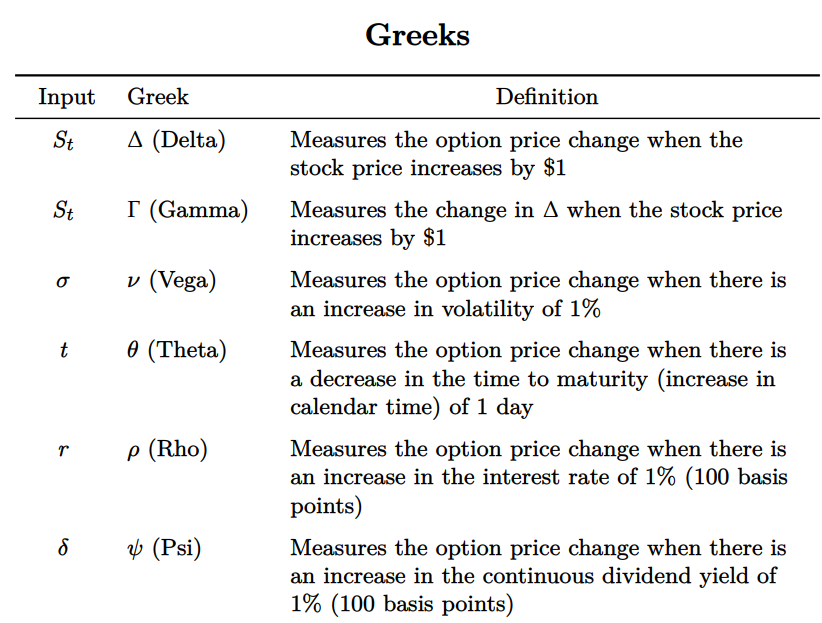

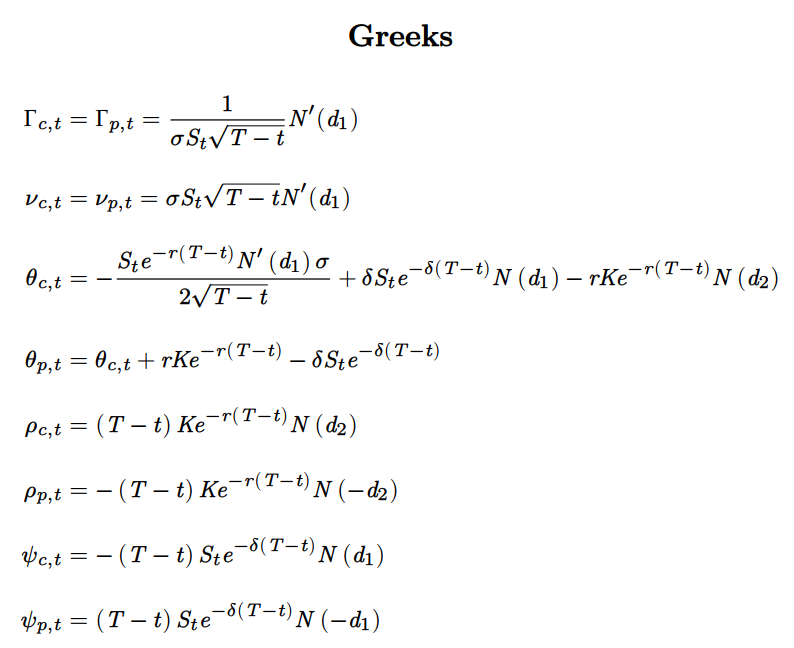

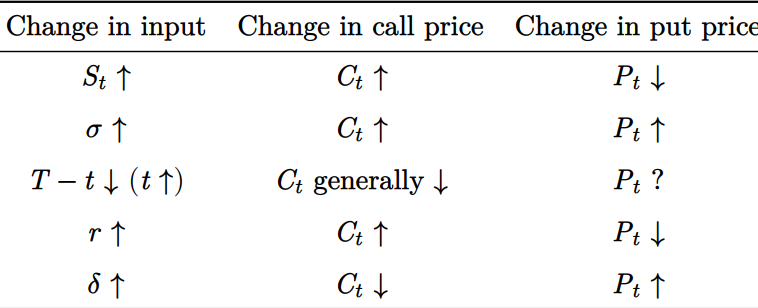

In [2]:
class europeanOption:
    def __init__(self, strike, ticker, expiry, spot, interestRate, impliedVolatility, divYield, optionType = "callOrPut", position = "longOrShort"):
        self.strike = round(strike, 5)
        self.ticker = ticker
        self.expiry = round(expiry, 5) #in years
        self.spot = round(spot, 5)
        self.interestRate = round(interestRate, 5)
        self.impliedVolatility = round(impliedVolatility, 5)
        self.divYield = round(divYield, 5)
        self.optionType = optionType.lower().strip()
        self.position = position.lower().strip()

    def positionfactor(self):
        if self.position == "long":
            return 1
        elif self.position == "short":
            return -1
        else:
            raise ValueError("Please specify whether you have a long or short position")

    def d1d2(self):
        d1 = (math.log(self.spot/self.strike) + (self.interestRate - self.divYield + (self.impliedVolatility**2)/2) * self.expiry)/(self.impliedVolatility*math.sqrt(self.expiry))
        d2 = d1 - self.impliedVolatility*math.sqrt(self.expiry)
        return d1, d2

    def price(self):
        if self.expiry <= 0:
            if self.optionType == "call":
                payoff = max(self.spot - self.strike, 0)
            else:
                payoff = max(self.strike - self.spot, 0)
            return payoff * self.positionfactor()
        d1, d2 = self.d1d2()
        if self.optionType == "call":
            return (self.spot * math.exp(-self.divYield*self.expiry) * norm.cdf(d1) - self.strike * math.exp(-self.interestRate*self.expiry) * norm.cdf(d2)) * self.positionfactor()
        elif self.optionType == "put":
            return (self.strike * math.exp(-self.interestRate*self.expiry) * norm.cdf(-d2) - self.spot * math.exp(-self.divYield*self.expiry) * norm.cdf(-d1)) * self.positionfactor()
        else:
            raise ValueError("Please enter either 'call' or 'put' as option type")
            
    def delta(self):
        if self.expiry <= 0:
            if self.optionType == "call":
                return (1.0 if self.spot > self.strike else 0.0) * self.positionfactor()
            else:
                return (-1.0 if self.spot < self.strike else 0.0) * self.positionfactor()
        d1, d2 = self.d1d2()
        if self.optionType =="call":
            return (math.exp(-self.divYield * self.expiry)) * (norm.cdf(d1)) * self.positionfactor()
        elif self.optionType =="put":
            return (math.exp(-self.divYield * self.expiry)) * (norm.cdf(d1)-1) * self.positionfactor()
        else:
            raise ValueError("Please enter either 'call' or 'put' as option type")
            
    def gamma(self):
        if self.expiry <= 0:
            return 0
        d1 = self.d1d2()[0]
        return norm.pdf(d1) * math.exp(-self.divYield * self.expiry) / (self.spot * self.impliedVolatility * math.sqrt(self.expiry))* self.positionfactor()
        
    def theta(self):
        if self.expiry <= 0:
            return 0
        d1, d2 = self.d1d2()
        if self.optionType == "call":
            return (-(self.spot * math.exp(-self.divYield * self.expiry) * norm.pdf(d1) * self.impliedVolatility) / (2 * math.sqrt(self.expiry)) + (self.divYield * self.spot * math.exp(-self.divYield * self.expiry) * norm.cdf(d1)) - (self.interestRate * self.strike * math.exp(-self.interestRate * self.expiry) * norm.cdf(d2))) / 365 * self.positionfactor()
        elif self.optionType == "put":
           return (-(self.spot * math.exp(-self.divYield * self.expiry) * norm.pdf(d1) * self.impliedVolatility) / (2 * math.sqrt(self.expiry)) - (self.divYield * self.spot * math.exp(-self.divYield * self.expiry) * norm.cdf(-d1)) + (self.interestRate * self.strike * math.exp(-self.interestRate * self.expiry) * norm.cdf(-d2))) / 365 * self.positionfactor()
        else:
            raise ValueError("Please enter either 'call' or 'put' as option type")
            
    def vega(self):
        if self.expiry <= 0:
            return 0
        d1, d2 = self.d1d2()
        return (math.exp(-self.divYield * self.expiry) * self.spot * norm.pdf(d1)*math.sqrt(self.expiry)/100) * self.positionfactor()
                
    def rho(self):
        if self.expiry <= 0:
            return 0
        d2 = self.d1d2()[1]
        if self.optionType == "call":
            return (self.strike * self.expiry * math.exp(-self.interestRate*self.expiry) * norm.cdf(d2))/100 * self.positionfactor()
        elif self.optionType == "put":
            return (-self.strike * self.expiry * math.exp(-self.interestRate*self.expiry) * norm.cdf(-d2))/100 * self.positionfactor()
        else:
            raise ValueError("Please enter either 'call' or 'put' as option type")


### **Using hypothetical portfolio to show instantaneous net greek exposure *and* greek evolution over five trading days to introduce stochastic exposure**

In [3]:
# SNDK US Equity                                                                                                    

# Date	Last Price	Volume	                                                    
# Fr	01/09/26	 	377.41	19,353,182	Fr	12/19/25	 	237.61	10,924,971	Fr	11/28/25	 	223.28	13,367,516
# Th	01/08/26	 	334.54	21,404,426	Th	12/18/25	 	219.46	9,924,101	Th	11/27/25	 	 	 
# We	01/07/26	 	353.56	14,886,066	We	12/17/25	 	206.83	8,232,320	We	11/26/25	 	215.04	43,000,870
# Tu	01/06/26	 	349.63	24,249,692	Tu	12/16/25	 	209.31	6,638,425	Tu	11/25/25	 	220.50	14,680,612
# Mo	01/05/26	 	274.08	9,812,554	Mo	12/15/25	 	201.87	6,264,976	Mo	11/24/25	 	226.96	13,798,895
 	 	 	 	 	 	 	 	 	 	 	 	 	 	 
# Fr	01/02/26	 	275.24	11,104,314	Fr	12/12/25	 	206.18	12,083,184	Fr	11/21/25	 	200.27	20,060,990
# Th	01/01/26	 	 	 	            Th	12/11/25	 	241.61	7,622,468	Th	11/20/25	 	195.96	26,590,861
# We	12/31/25	 	237.38	4,180,414	We	12/10/25	 	232.86	6,090,435	We	11/19/25	 	245.96	12,005,841
# Tu	12/30/25	 	240.22	6,617,041	Tu	12/09/25	 	219.46	6,299,028	Tu	11/18/25	 	244.93	16,433,943
# Mo	12/29/25	 	244.25	5,706,206	Mo	12/08/25	 	225.47	8,710,023	Mo	11/17/25	 	265.88	14,211,495
 	 	 	 	 	 	 	 	 	 	 	 	 	 	 
# Fr	12/26/25	 	250.05	5,553,664	Fr	12/05/25	 	228.47	8,451,321	Fr	11/14/25	 	254.16	19,464,398
# Th	12/25/25	 	 	                Th	12/04/25	 	213.31	12,166,492	Th	11/13/25	 	243.57	23,274,911
# We	12/24/25	 	250.08	5,642,556	We	12/03/25	 	194.38	9,868,223	We	11/12/25	 	283.10	13,730,302
# Tu	12/23/25	 	244.90	5,305,676	Tu	12/02/25	 	205.35	11,095,750	Tu	11/11/25	 	271.58	12,180,912
# Mo	12/22/25	 	241.05	8,663,399	Mo	12/01/25	 	210.17	10,280,917	Mo	11/10/25	 	267.95	15,276,390

### **Hypothetical Portfolio 1, Strangle on SNDK**

In [4]:
#11/17/25: $SNDK spot = 265.88
#Assuming strangle strategy, 1:1 ratio call to put
#Assuming 1 contract = 100 shares

In [5]:
#define inputs since they will match for a strangle
ticker = 'SNDK'
spot = 265.88 #given using data above
T = 60/365 #in years
r = .055
vol = .20
div = .01
putstrike = 240
callstrike = 280

longcall = europeanOption(
    strike = callstrike,
    ticker = ticker,
    expiry = T,
    spot = spot,
    interestRate = r,
    impliedVolatility = vol,
    divYield = div,
    optionType='call',
    position='long'
)
    
longput = europeanOption(
    strike = putstrike,
    ticker = ticker,
    expiry = T,
    spot = spot,
    interestRate = r,
    impliedVolatility = vol,
    divYield = div,
    optionType='put',
    position='long'
)

Current portfolio exposure at t=0 given Hypothetical Portfolio #1

In [6]:
contractsize = 100
Cost = (longcall.price() + longput.price()) * contractsize
Delta = (longcall.delta() + longput.delta()) * contractsize 
Gamma = (longcall.gamma() + longput.gamma()) * contractsize 
Theta = (longcall.theta() + longput.theta()) * contractsize  
Vega = (longcall.vega() + longput.vega()) * contractsize  
Rho = (longcall.rho() + longput.rho()) * contractsize 
print(f"Cost = {Cost:.3f}") 
print(f"Delta = {Delta:.3f}")
print(f"Gamma = {Gamma:.3f}")
print(f"Theta = {Theta:.3f}")
print(f"Vega = {Vega:.3f}")
print(f"Rho = {Rho:.3f}")

Cost = 486.644
Delta = 22.437
Gamma = 2.324
Theta = -9.663
Vega = 54.003
Rho = 9.006


Theoretical hedging requirements to be delta neutral, less applicable for a Strangle Strategy

In [7]:
def hedgingreq(Delta):
    shares = abs(Delta)
    if Delta > 0:
        return f"Sell {shares:.2f} shares short to be delta neutral"
    if Delta < 0:
        return f"Buy {shares:.2f} shares long to be delta neutral"
print(hedgingreq(Delta))

Sell 22.44 shares short to be delta neutral


Plotting stochastic Greek exposure to $SNDK given Hypothetical Portfolio #1 over five trading days

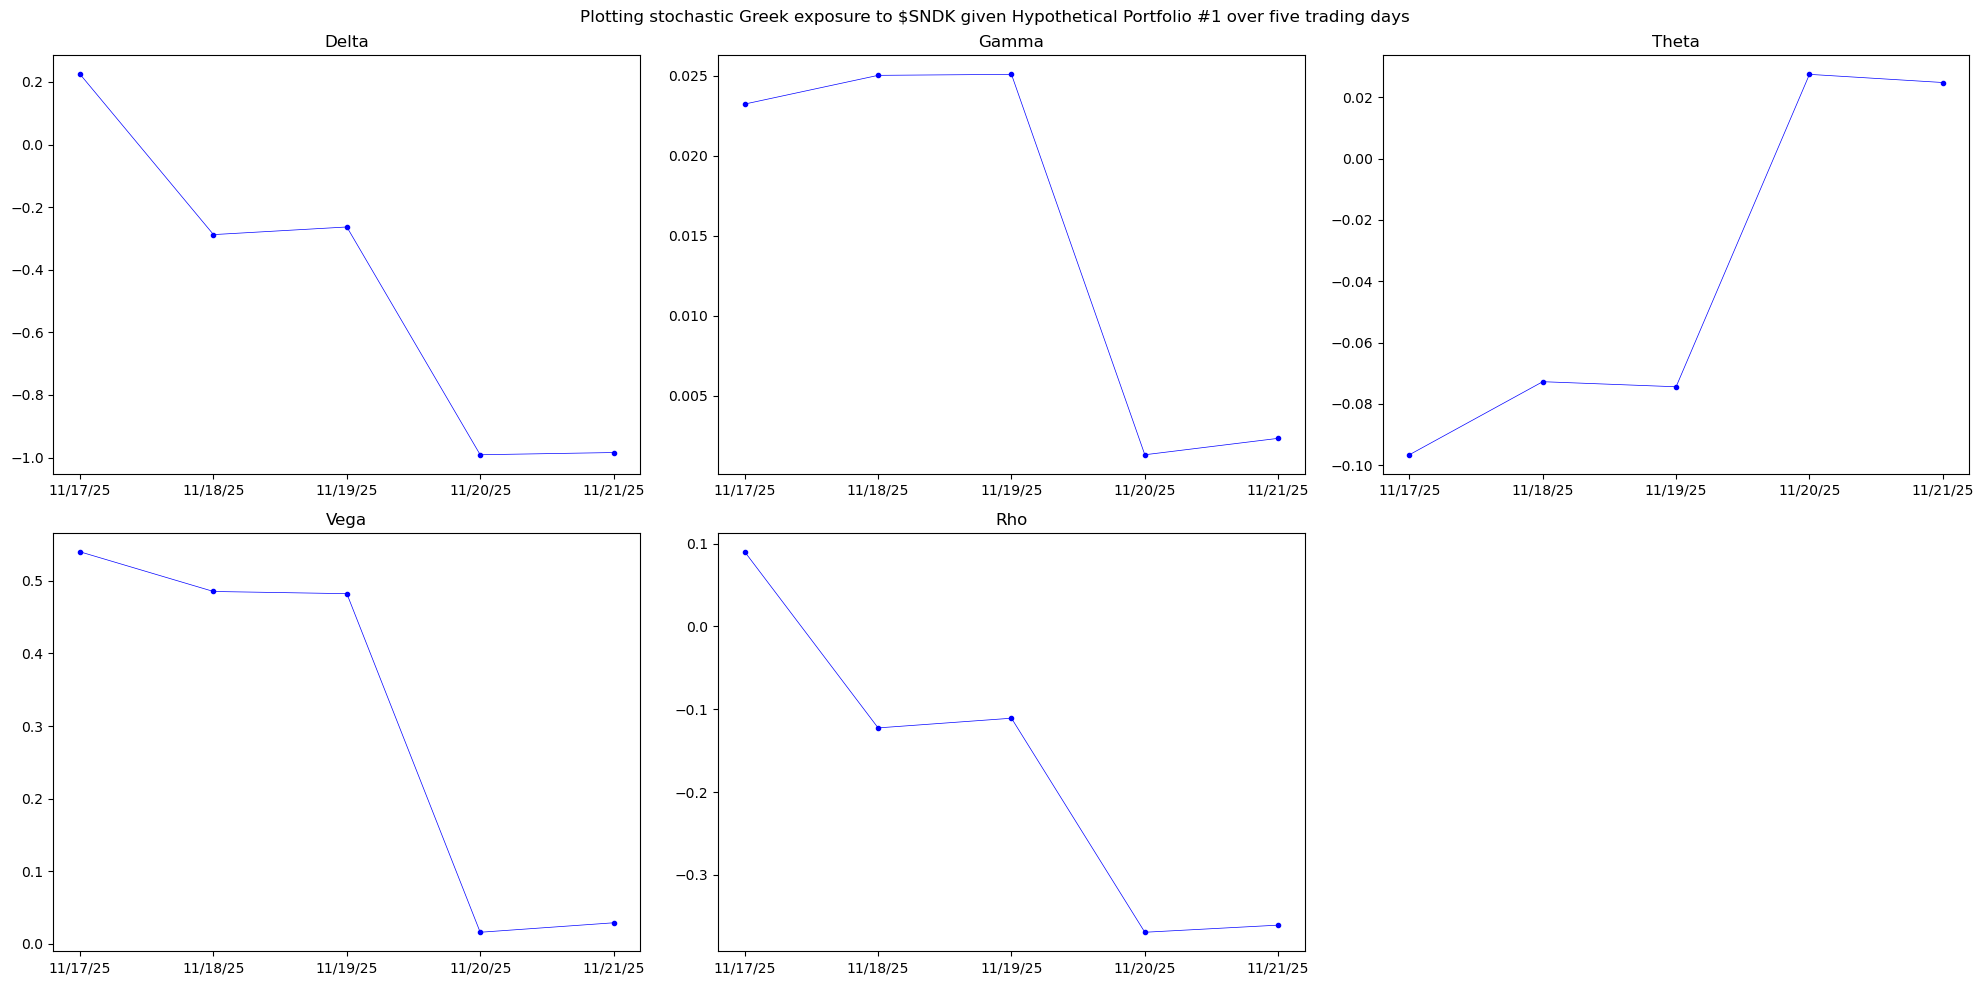

In [8]:
t0, t1, t2, t3, t4 = 265.88, 244.93, 245.96, 195.96, 200.27 #from above
startingT = T
spots = [t0, t1, t2, t3, t4]
deltas, gammas, thetas, vegas, rhos = [], [], [], [], []

for i, spot in enumerate(spots):
    currentT = startingT - (i/365)
    longcall = europeanOption(callstrike, ticker, currentT, spot, r, vol, div, "call", "long")
    longput = europeanOption(putstrike, ticker, currentT, spot, r, vol, div, "put", "long")
    
    deltas.append(longcall.delta() + longput.delta())
    gammas.append(longcall.gamma() + longput.gamma())
    thetas.append(longcall.theta() + longput.theta())
    vegas.append(longcall.vega() + longput.vega())
    rhos.append(longcall.rho() + longput.rho())

GreeksData = [deltas, gammas, thetas, vegas, rhos]
Greeks = ["Delta", "Gamma", "Theta", "Vega", "Rho"]
Dates = ["11/17/25", "11/18/25", "11/19/25", "11/20/25", "11/21/25"]

fig, ax = plt.subplots(2, 3, figsize = (20,10))
axes = ax.flatten()
for i in range(len(GreeksData)):
    axes[i].plot(Dates, GreeksData[i], marker = '.', color = 'b', linewidth = 0.5)
    axes[i].set_title(Greeks[i])
axes[5].axis('off')
fig.suptitle("Plotting stochastic Greek exposure to $SNDK given Hypothetical Portfolio #1 over five trading days")
plt.tight_layout()
plt.show()


### Adding PnL

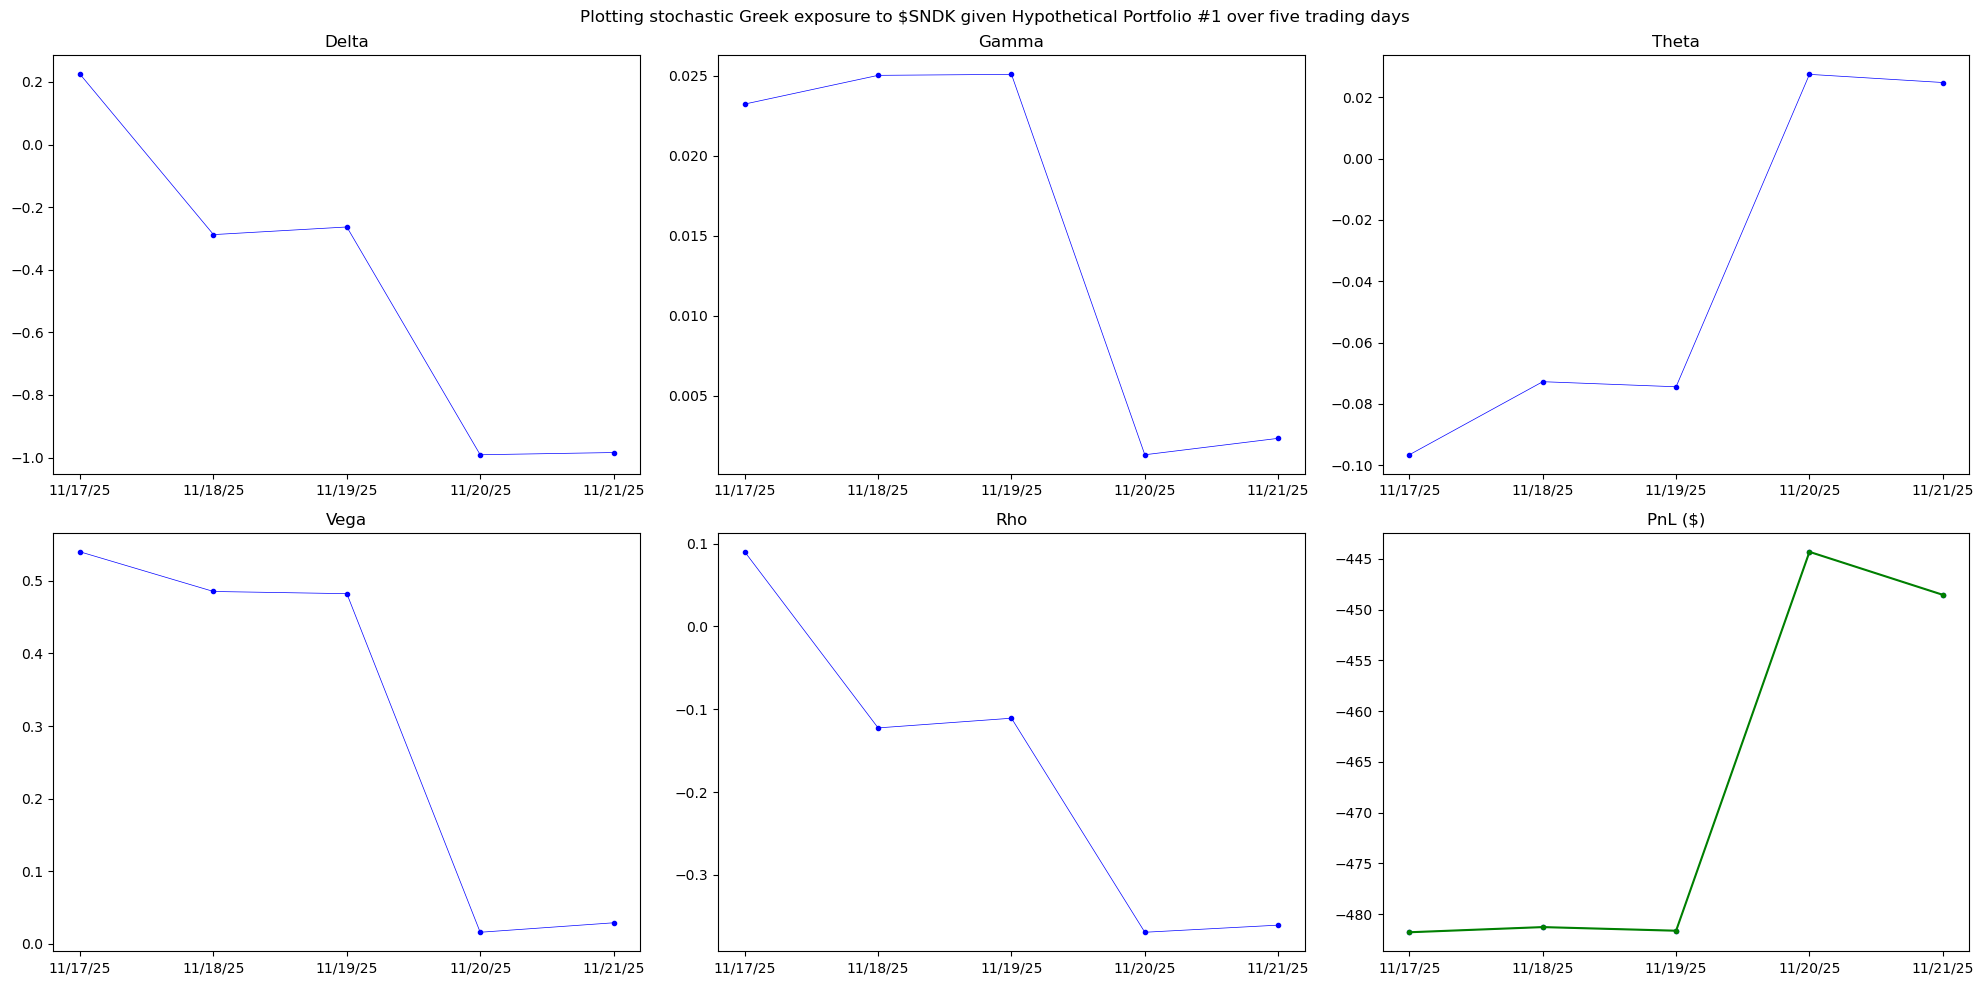

In [9]:
t0, t1, t2, t3, t4 = 265.88, 244.93, 245.96, 195.96, 200.27 #from above
startingT = T
spots = [t0, t1, t2, t3, t4]
deltas, gammas, thetas, vegas, rhos, pnl = [], [], [], [], [], []

initialPNL = -Cost


for i, spot in enumerate(spots):
    currentT = startingT - (i/365)
    longcall = europeanOption(callstrike, ticker, currentT, spot, r, vol, div, "call", "long")
    longput = europeanOption(putstrike, ticker, currentT, spot, r, vol, div, "put", "long")
    
    deltas.append(longcall.delta() + longput.delta())
    gammas.append(longcall.gamma() + longput.gamma())
    thetas.append(longcall.theta() + longput.theta())
    vegas.append(longcall.vega() + longput.vega())
    rhos.append(longcall.rho() + longput.rho())

    currentPNL = (longcall.price() + longput.price()) + initialPNL
    pnl.append(currentPNL)

GreeksData = [deltas, gammas, thetas, vegas, rhos, pnl]
Greeks = ["Delta", "Gamma", "Theta", "Vega", "Rho", "PnL ($)"]
Dates = ["11/17/25", "11/18/25", "11/19/25", "11/20/25", "11/21/25"]

fig, ax = plt.subplots(2, 3, figsize = (20,10))
axes = ax.flatten()
for i in range(len(GreeksData)):
    axes[i].plot(Dates, GreeksData[i], marker = '.', color = 'b', linewidth = 0.5)
    axes[i].set_title(Greeks[i])
axes[5].plot(Dates, pnl, marker = '.', color = 'g', linewidth = 1.5)

fig.suptitle("Plotting stochastic Greek exposure to $SNDK given Hypothetical Portfolio #1 over five trading days")
plt.tight_layout()
plt.show()


### Hypothetical Portfolio #2, Market Making Portfolio

In [10]:
#For ticker $SNDK, assume "random" non-delta neutral market making portfolio. This portfolio may be non-realistic based on trading/volume/transaction/hedging considerations but is just to show how greeks can be calculated given myriad of different positions with aim of achieving delta-neutrality

In [11]:
#Assuming transaction volume of 1 contract = 100 shares for all
#Assuming constant r for all
#Assuming constant dividend yield for all
#Assuming simplified implied volatility: .3 for < 90 days, .2 for >= 90 days

ticker = 'SNDK'
spot = 265.88 #given using data above
r = .055
div = .01
ivshort = .3
ivlong = .2


longcall = europeanOption( #zero-day option
    strike = 275,
    ticker = ticker,
    expiry = 1/365,
    spot = spot,
    interestRate = r,
    impliedVolatility = ivshort,
    divYield = div,
    optionType='call',
    position='long'
)
    
longput = europeanOption(
    strike = 220,
    ticker = ticker,
    expiry = 270/365,
    spot = spot,
    interestRate = r,
    impliedVolatility = ivlong,
    divYield = div,
    optionType='put',
    position='long'
)

shortcall = europeanOption(
    strike = 300,
    ticker = ticker,
    expiry = 15/365,
    spot = spot,
    interestRate = r,
    impliedVolatility = ivshort,
    divYield = div,
    optionType='call',
    position='short'
)

shortput = europeanOption( 
    strike = 270, #in the money
    ticker = ticker,
    expiry = 365/365,
    spot = spot,
    interestRate = r,
    impliedVolatility = ivlong,
    divYield = div,
    optionType='put',
    position='short'
)

longcall2 = europeanOption(
    strike = 340,
    ticker = ticker,
    expiry = 45/365,
    spot = spot,
    interestRate = r,
    impliedVolatility = ivshort,
    divYield = div,
    optionType='call',
    position='long'
)

shortcall2 = europeanOption(
    strike = 320,
    ticker = ticker,
    expiry = 90/365,
    spot = spot,
    interestRate = r,
    impliedVolatility = ivlong,
    divYield = div,
    optionType='call',
    position='short'
)


Current portfolio exposure at t=0 given Hypothetical Portfolio #2

In [12]:
contractsize = 100
Cost = (longcall.price() + longput.price() + shortcall.price() + shortput.price() + longcall2.price() + shortcall2.price()) * contractsize 
Delta = (longcall.delta() + longput.delta() + shortcall.delta() + shortput.delta() + longcall2.delta() + shortcall2.delta()) * contractsize 
Gamma = (longcall.gamma() + longput.gamma() + shortcall.gamma() + shortput.gamma() + longcall2.gamma() + shortcall2.gamma()) * contractsize 
Theta = (longcall.theta() + longput.theta() + shortcall.theta() + shortput.theta() + longcall2.theta() + shortcall2.theta()) * contractsize 
Vega = (longcall.vega() + longput.vega() + shortcall.vega() + shortput.vega() + longcall2.vega() + shortcall2.vega()) * contractsize 
Rho = (longcall.rho() + longput.rho() + shortcall.rho() + shortput.rho() + longcall2.rho() + shortcall2.rho()) * contractsize 
print(f"Cost = {Cost:.3f}")
print(f"Delta = {Delta:.3f}")
print(f"Gamma = {Gamma:.3f}")
print(f"Theta = {Theta:.3f}")
print(f"Vega = {Vega:.3f}")
print(f"Rho = {Rho:.3f}")

Cost = -1565.841
Delta = 27.314
Gamma = -0.023
Theta = -4.508
Vega = -78.920
Rho = 102.508


Theoretical hedging requirements to be delta neutral

In [13]:
def hedgingreq(Delta):
    shares = abs(Delta)
    if Delta > 0:
        return f"Sell {shares:.2f} shares short to be delta neutral"
    if Delta < 0:
        return f"Buy {shares:.2f} shares long to be delta neutral"
print(hedgingreq(Delta))

Sell 27.31 shares short to be delta neutral


In [14]:
#Plotting stochastic Greek exposure to $SNDK given Hypothetical Portfolio #2 over five trading days, adding checks to account for expiry over those days

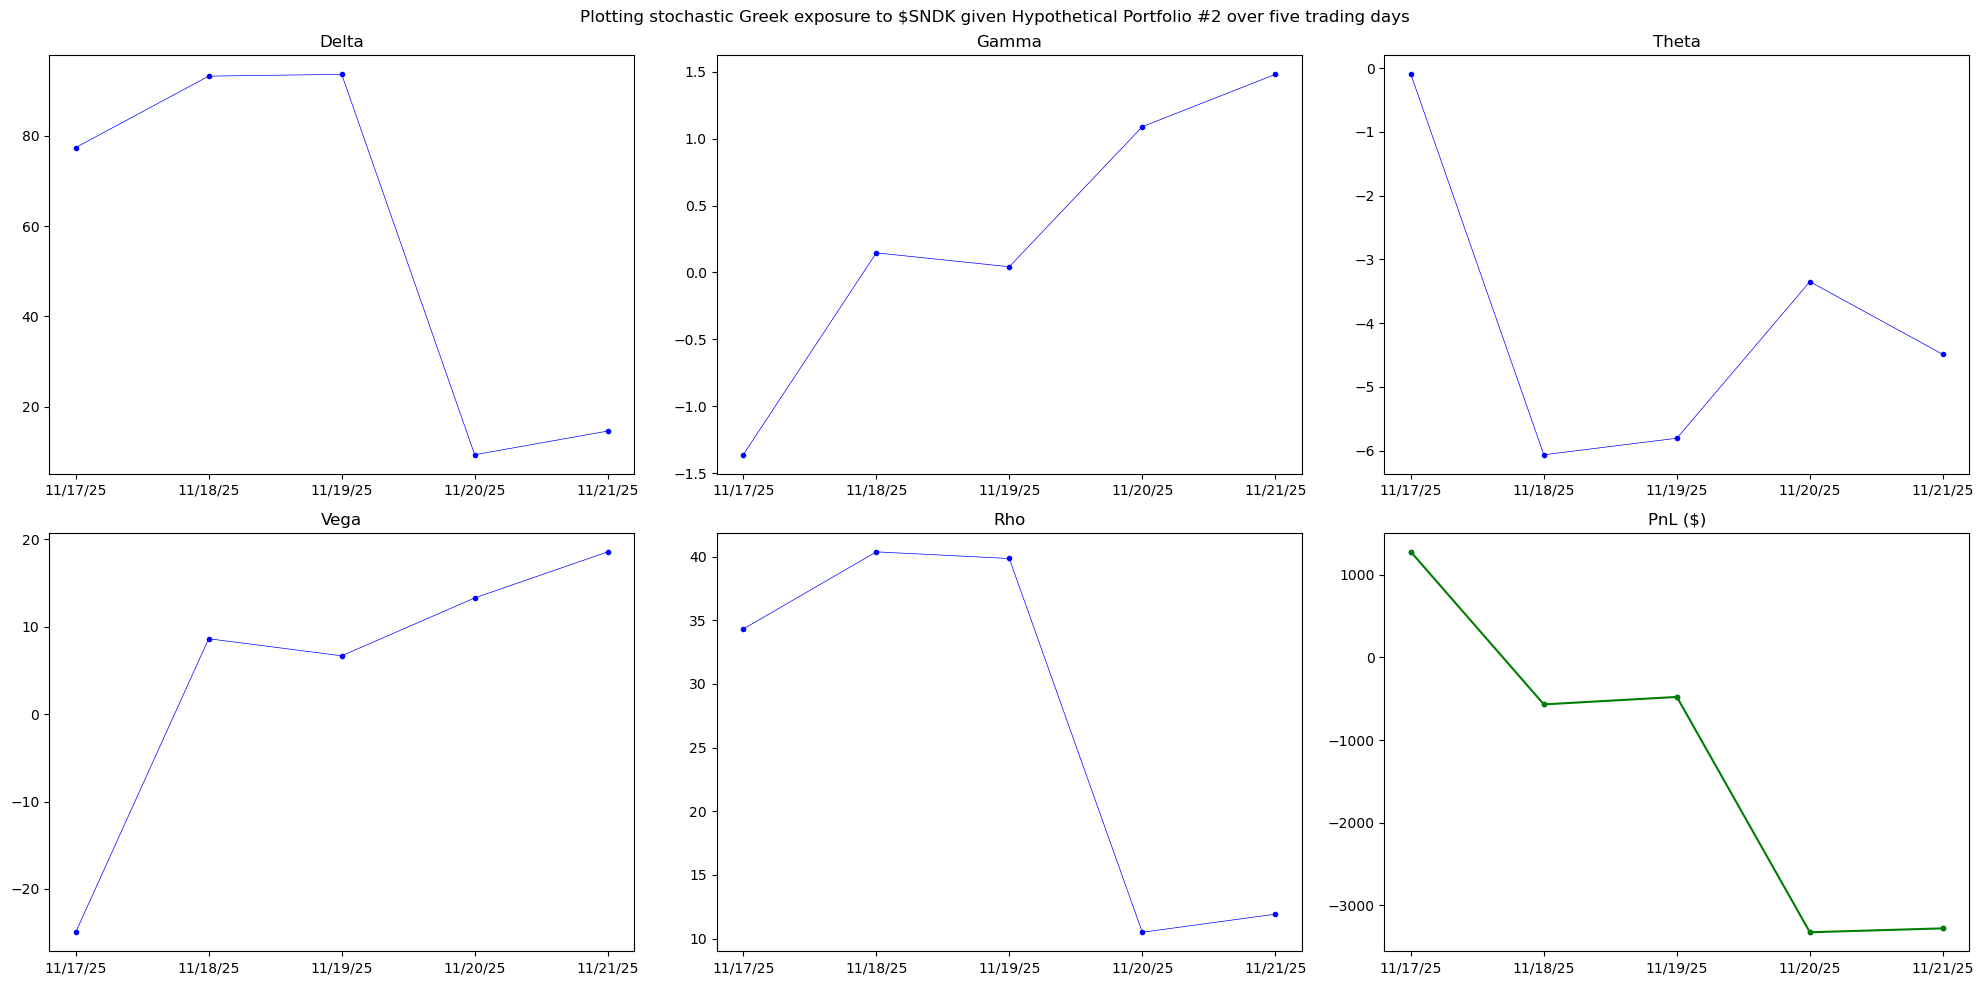

In [15]:
t0, t1, t2, t3, t4 = 265.88, 244.93, 245.96, 195.96, 200.27 #from above
startingT = T
spots = [t0, t1, t2, t3, t4]
deltas, gammas, thetas, vegas, rhos, pnl = [], [], [], [], [], []

initialPNL = -Cost/contractsize
realizedPNL = initialPNL

for option in [longcall, longput, shortcall, shortput, longcall2, shortcall2]:
        option.expired = False
        option.settled = False

for i, spot in enumerate(spots):
    currentT = startingT - (i/365)
    spotPrice = 0

    for option in [longcall, longput, shortcall, shortput, longcall2, shortcall2]:
        option.spot = spot

        if  currentT <= 0 and not option.expired:
            option.expired = True
            if not option.settled:
                realizedPNL += option.price()
                option.settled = True

        if not option.expired:
            option.expiry = currentT
            spotPrice += option.price()
        
    deltas.append((longcall.delta() + longput.delta() + shortcall.delta() + shortput.delta() + longcall2.delta() + shortcall2.delta()) * contractsize)
    gammas.append((longcall.gamma() + longput.gamma() + shortcall.gamma() + shortput.gamma() + longcall2.gamma() + shortcall2.gamma()) * contractsize)
    thetas.append((longcall.theta() + longput.theta() + shortcall.theta() + shortput.theta() + longcall2.theta() + shortcall2.theta()) * contractsize)
    vegas.append((longcall.vega() + longput.vega() + shortcall.vega() + shortput.vega() + longcall2.vega() + shortcall2.vega()) * contractsize)
    rhos.append((longcall.rho() + longput.rho() + shortcall.rho() + shortput.rho() + longcall2.rho() + shortcall2.rho()) * contractsize)
    pnl.append((realizedPNL + spotPrice) * contractsize)
    
GreeksData = [deltas, gammas, thetas, vegas, rhos, pnl]
Greeks = ["Delta", "Gamma", "Theta", "Vega", "Rho", "PnL ($)"] 
Dates = ["11/17/25", "11/18/25", "11/19/25", "11/20/25", "11/21/25"]

fig, ax = plt.subplots(2, 3, figsize = (20,10))
axes = ax.flatten()
for i in range(len(GreeksData)):
    axes[i].plot(Dates, GreeksData[i], marker = '.', color = 'b', linewidth = 0.5)
    axes[i].set_title(Greeks[i])
axes[5].plot(Dates, pnl, marker = '.', color = 'g', linewidth = 1.5)

fig.suptitle("Plotting stochastic Greek exposure to $SNDK given Hypothetical Portfolio #2 over five trading days")
plt.tight_layout()
plt.show()
